# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Muhamad Nafi Mulyo | 5054251005 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Setting tampilan plot agar rapi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
# 1. Load dataset
df = pd.read_csv("data.csv")

# Tampilkan 5 baris pertama
print("5 Baris Pertama Data")
display(df.head())

# Tampilkan informasi struktur data (tipe data & non-null count)
print("\nInfo Dataset")
df.info()

# Tampilkan deskripsi statistik & cek missing value
print("\nJumlah Missing Value per Kolom")
print(df.isnull().sum()[df.isnull().sum() > 0])


5 Baris Pertama Data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Info Dataset
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se           

/tmp/ipykernel_51142/3428962496.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='diagnosis', palette=['#2ecc71', '#e74c3c'])


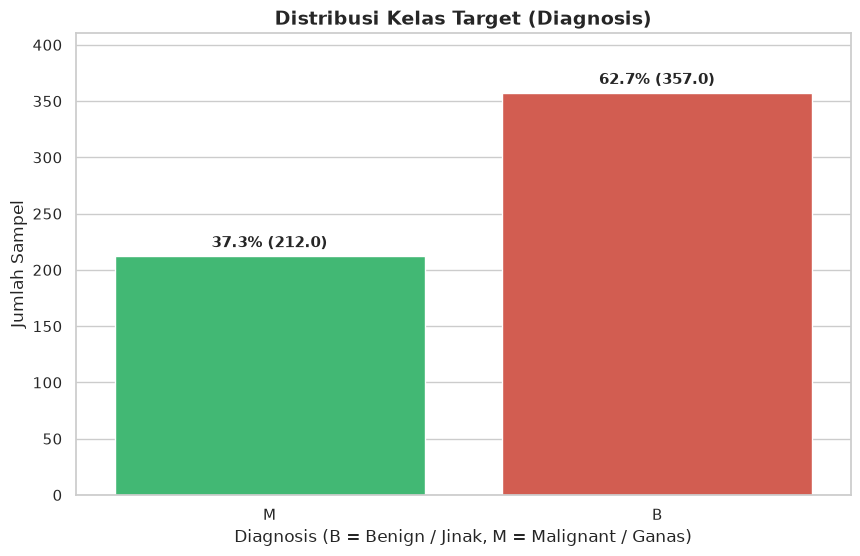

Rasio Kelas (%):
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
# Tampilkan distribusi kelas target (diagnosis)
ax = sns.countplot(data=df, x='diagnosis', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Kelas Target (Diagnosis)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis (B = Benign / Jinak, M = Malignant / Ganas)')
plt.ylabel('Jumlah Sampel')

# Tambahkan angka & persentase di atas bar
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}% ({height})'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height + 5),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, max(df['diagnosis'].value_counts()) * 1.15)
plt.show()

# Print rasio numerik
print("Rasio Kelas (%):")
print(df['diagnosis'].value_counts(normalize=True) * 100)


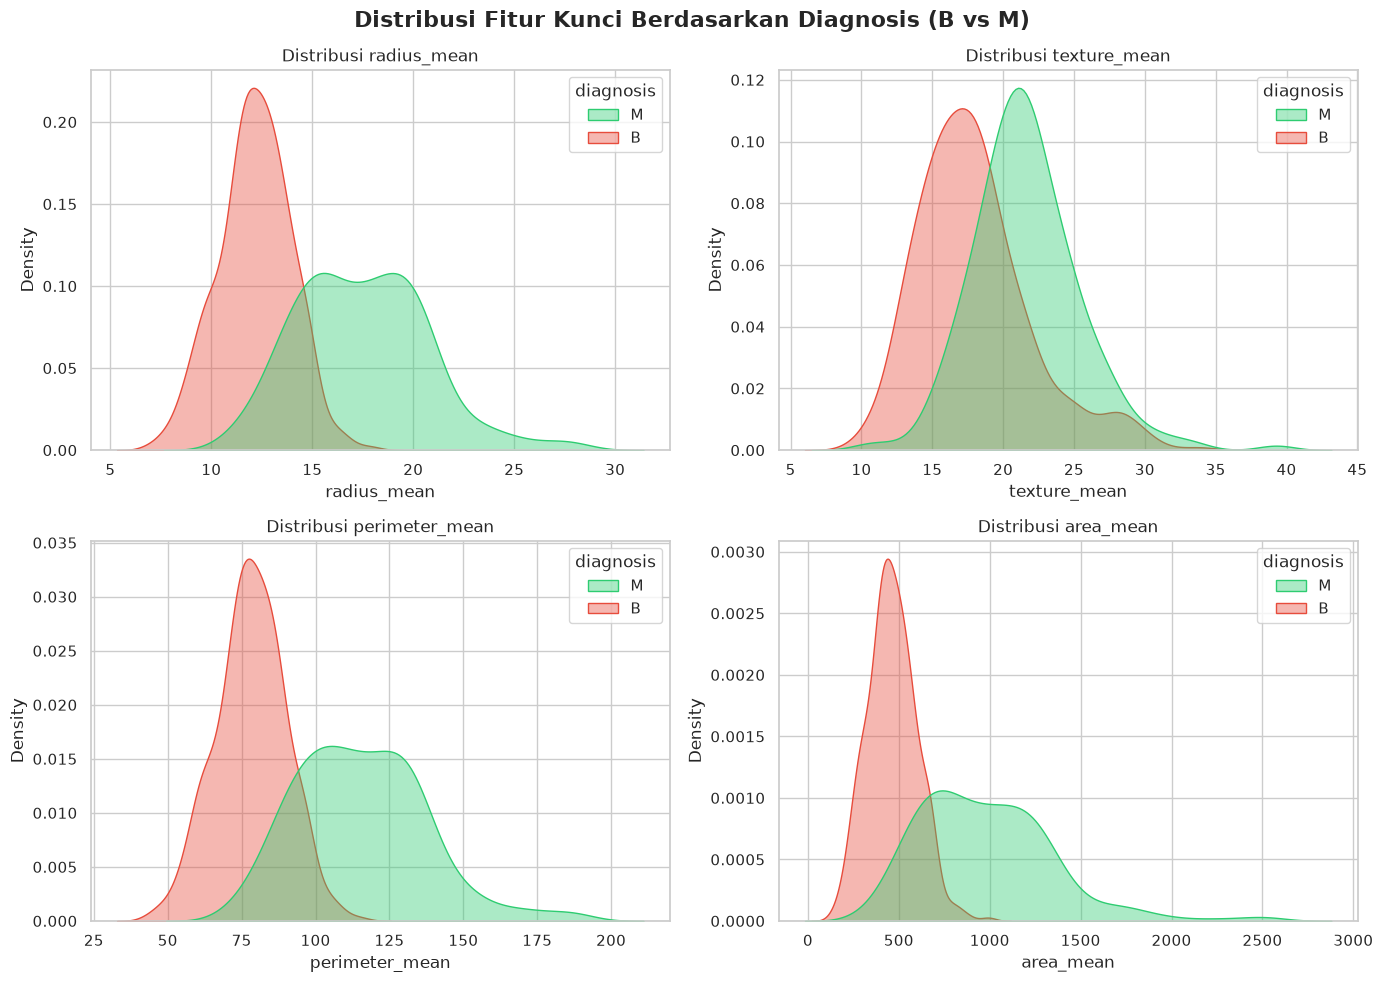

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
# Pilih 4 fitur representatif untuk melihat keterpisahan kelas
features_to_plot = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Fitur Kunci Berdasarkan Diagnosis (B vs M)', fontsize=16, fontweight='bold')

for idx, feature in enumerate(features_to_plot):
    row, col = idx // 2, idx % 2
    sns.kdeplot(data=df, x=feature, hue='diagnosis', fill=True, common_norm=False, 
                palette=['#2ecc71', '#e74c3c'], ax=axes[row, col], alpha=0.4)
    axes[row, col].set_title(f'Distribusi {feature}', fontsize=12)

plt.tight_layout()
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# 1. Buang kolom 'id' (noise) dan 'Unnamed: 32' (garbage null column)
df_clean = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# 2. Encode target 'diagnosis': M (Malignant) -> 1, B (Benign) -> 0
df_clean['diagnosis'] = df_clean['diagnosis'].map({'M': 1, 'B': 0})

print("Ukuran data setelah dibersihkan:", df_clean.shape)
print("Missing values tersisa:", df_clean.isnull().sum().sum())


Ukuran data setelah dibersihkan: (569, 31)
Missing values tersisa: 0


In [6]:
# Pisahkan fitur (X) dan label target (y)
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

# Bagi data 80% Train : 20% Test dengan stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test.shape}")
print("\nProporsi kelas di y_train (%):")
print(y_train.value_counts(normalize=True) * 100)

Ukuran X_train: (455, 30)
Ukuran X_test : (114, 30)

Proporsi kelas di y_train (%):
diagnosis
0    62.637363
1    37.362637
Name: proportion, dtype: float64


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [7]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
# Inisialisasi StandardScaler
scaler = StandardScaler()

# Wajib: fit_transform HANYA pada X_train, transform SAJA pada X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler sukses!")
print("Cek Mean X_train_scaled (mendekati 0):", np.mean(X_train_scaled[:, 0]).round(4))
print("Cek Std  X_train_scaled (harus 1.0)  :", np.std(X_train_scaled[:, 0]).round(4))


StandardScaler sukses!
Cek Mean X_train_scaled (mendekati 0): -0.0
Cek Std  X_train_scaled (harus 1.0)  : 1.0


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [8]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
# 1. Inisialisasi & latih SVC dengan kernel='linear'
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

# 2. Prediksi pada data train dan data test
y_pred_train_linear = svm_linear.predict(X_train_scaled)
y_pred_test_linear = svm_linear.predict(X_test_scaled)

# 3. Hitung akurasi
acc_train_linear = accuracy_score(y_train, y_pred_train_linear)
acc_test_linear = accuracy_score(y_test, y_pred_test_linear)

print("=== Hasil SVM Kernel Linear (C=1.0) ===")
print(f"Akurasi Training : {acc_train_linear * 100:.2f}%")
print(f"Akurasi Testing  : {acc_test_linear * 100:.2f}%")


=== Hasil SVM Kernel Linear (C=1.0) ===
Akurasi Training : 98.90%
Akurasi Testing  : 96.49%


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [9]:

# 1. Inisialisasi & latih SVC dengan kernel='rbf' (C=1.0 sama seperti linear agar fair)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

# 2. Prediksi pada data train dan data test
y_pred_train_rbf = svm_rbf.predict(X_train_scaled)
y_pred_test_rbf = svm_rbf.predict(X_test_scaled)

# 3. Hitung akurasi
acc_train_rbf = accuracy_score(y_train, y_pred_train_rbf)
acc_test_rbf = accuracy_score(y_test, y_pred_test_rbf)

print("=== Hasil SVM Kernel RBF (C=1.0) ===")
print(f"Akurasi Training : {acc_train_rbf * 100:.2f}%")
print(f"Akurasi Testing  : {acc_test_rbf * 100:.2f}%")


=== Hasil SVM Kernel RBF (C=1.0) ===
Akurasi Training : 98.68%
Akurasi Testing  : 97.37%


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

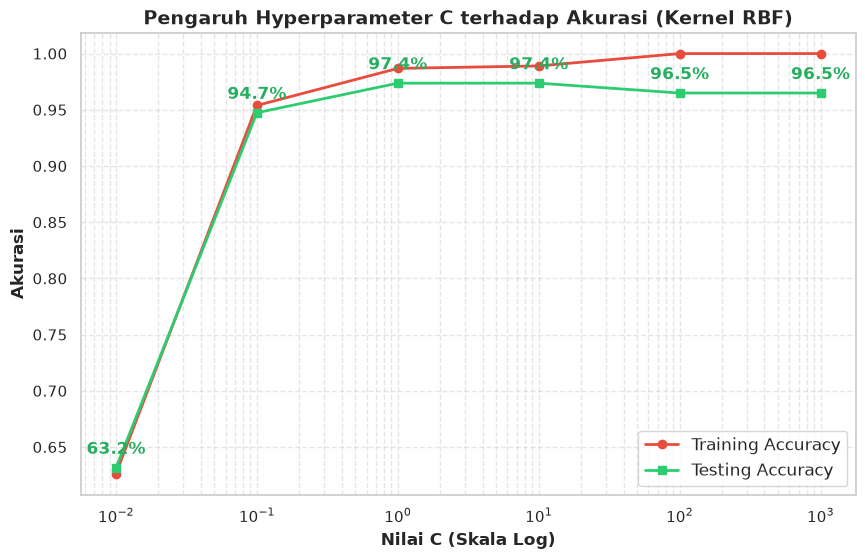

In [10]:
# List nilai C yang akan dieksperimenkan (skala logaritmik)
C_values = [0.01, 0.1, 1, 10, 100, 1000]

train_accuracies = []
test_accuracies = []

for c in C_values:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    
    acc_train = accuracy_score(y_train, model.predict(X_train_scaled))
    acc_test = accuracy_score(y_test, model.predict(X_test_scaled))
    
    train_accuracies.append(acc_train)
    test_accuracies.append(acc_test)

# Plot grafik akurasi Training vs Testing terhadap nilai C
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy', linewidth=2, color='#e74c3c')
plt.plot(C_values, test_accuracies, marker='s', label='Testing Accuracy', linewidth=2, color='#2ecc71')

plt.xscale('log')  # Sumbu X logaritmik
plt.xlabel('Nilai C (Skala Log)', fontsize=12, fontweight='bold')
plt.ylabel('Akurasi', fontsize=12, fontweight='bold')
plt.title('Pengaruh Hyperparameter C terhadap Akurasi (Kernel RBF)', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Tampilkan persentase akurasi pada poin plot
for idx, c in enumerate(C_values):
    plt.annotate(f"{test_accuracies[idx]*100:.1f}%", (c, test_accuracies[idx]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#27ae60')

plt.show()

# 4. Evaluasi Model

In [11]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
# Re-fit model linear dan RBF terbaik (C=1.0)
svm_lin = SVC(kernel='linear', C=1.0, random_state=42).fit(X_train_scaled, y_train)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42).fit(X_train_scaled, y_train)

metrics = []
for name, model in [('Linear (C=1.0)', svm_lin), ('RBF (C=1.0)', svm_rbf)]:
    y_pred = model.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)
    metrics.append({
        'Model': name,
        'Accuracy': f"{report['accuracy']*100:.2f}%",
        'Precision (M)': f"{report['1']['precision']*100:.2f}%",
        'Recall (M)': f"{report['1']['recall']*100:.2f}%",
        'F1-Score (M)': f"{report['1']['f1-score']*100:.2f}%"
    })

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

,Model,Accuracy,Precision (M),Recall (M),F1-Score (M)
0,Linear (C=1.0),96.49%,100.00%,90.48%,95.00%
1,RBF (C=1.0),97.37%,100.00%,92.86%,96.30%


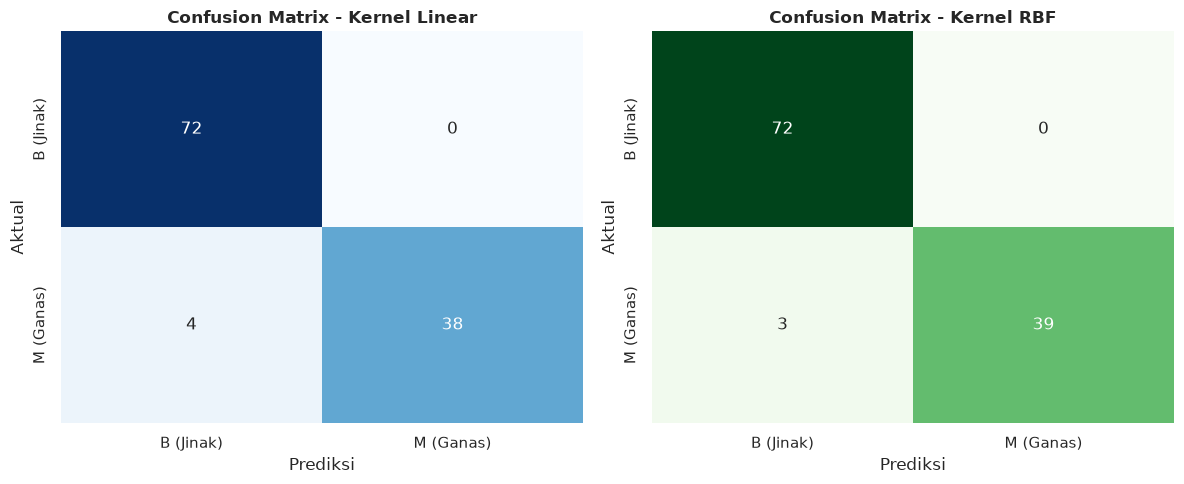

In [12]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lin = confusion_matrix(y_test, svm_lin.predict(X_test_scaled))
cm_rbf = confusion_matrix(y_test, svm_rbf.predict(X_test_scaled))

sns.heatmap(cm_lin, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['B (Jinak)', 'M (Ganas)'], yticklabels=['B (Jinak)', 'M (Ganas)'])
axes[0].set_title('Confusion Matrix - Kernel Linear', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['B (Jinak)', 'M (Ganas)'], yticklabels=['B (Jinak)', 'M (Ganas)'])
axes[1].set_title('Confusion Matrix - Kernel RBF', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

In [13]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
print(f"Jumlah Support Vectors - Kernel Linear: {svm_lin.n_support_.sum()} titik (B: {svm_lin.n_support_[0]}, M: {svm_lin.n_support_[1]})")
print(f"Jumlah Support Vectors - Kernel RBF   : {svm_rbf.n_support_.sum()} titik (B: {svm_rbf.n_support_[0]}, M: {svm_rbf.n_support_[1]})")

Jumlah Support Vectors - Kernel Linear: 38 titik (B: 19, M: 19)
Jumlah Support Vectors - Kernel RBF   : 107 titik (B: 50, M: 57)


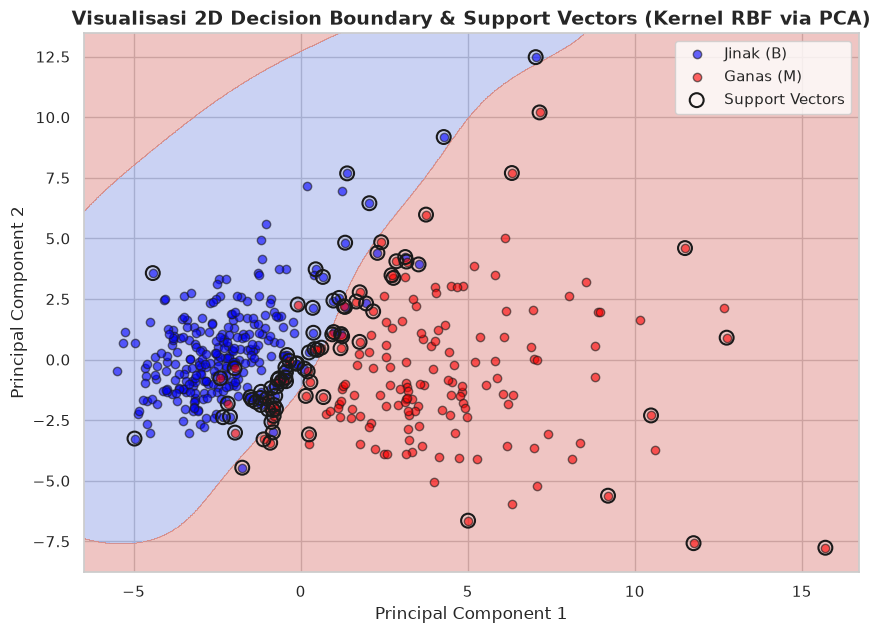

In [14]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
from sklearn.decomposition import PCA

# Reduksi data dari 30D ke 2D untuk visualisasi
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Latih SVM RBF di ruang 2D PCA
svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_2d.fit(X_train_pca, y_train)

# Buat grid kontur 2D
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], c='blue', label='Jinak (B)', alpha=0.6, edgecolors='k')
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], c='red', label='Ganas (M)', alpha=0.6, edgecolors='k')

# Highlight Support Vectors
sv = svm_2d.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')

plt.title('Visualisasi 2D Decision Boundary & Support Vectors (Kernel RBF via PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

1. Perbandingan Kernel Linear vs RBF:
   - Kernel Linear mencapai akurasi testing 96.49%, sedangkan RBF mencapai 97.37%.
   - Kernel RBF mengunggulikernel Linear karena mampu membentuk decision boundary yang non-linear (melengkung), sehingga mampu menangkap pola pada titik-titik perbatasan yang tumpang tindih ringan. Pada kasus medis, RBF berhasil meningkatkan Recall dari 90.48% menjadi 92.86% (mengurangi False Negative dari 4 menjadi 3 pasien).

2. Temuan Eksperimen Regularisasi (Nilai C):
   - Pada C = 0.01, model mengalami Underfitting (akurasi ~63.2%) karena margin terlalu dipaksakan lebar.
   - Nilai C = 1.0 merupakan titik optimal (Sweet Spot) dengan akurasi test tertinggi (97.4%).
   - Pada C >= 100, model mulai menunjukkan gejala Overfitting, ditandai dengan akurasi training mencapai 100%, namun akurasi testing mengalami penurunan ke 96.5%.

3. Support Vectors:
   - Support Vectors terletak di sepanjang margin perbatasan antar kelas. Jumlah dan posisi support vectors menentukan bentuk decision boundary. Pada RBF, support vectors menangkap kompleksitas batas non-linear secara presisi.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulan:
1. Feature scaling (StandardScaler) sangat krusial untuk SVM agar tidak ada fitur berkisar besar yang mendominasi perhitungan jarak.
2. Model SVM dengan Kernel RBF pada C = 1.0 memberikan performa terbaik dengan Akurasi 97.37% dan Recall 92.86%.
3. Penentuan nilai C yang tepat sangat penting untuk menjaga trade-off antara bias dan variance.

Saran:
1. Melakukan hyperparameter tuning lebih lanjut menggunakan GridSearchCV untuk mencari kombinasi C dan gamma yang optimal secara bersamaan.
2. Mencoba teknik penanganan imbalance data (seperti SMOTE atau setting class_weight='balanced') untuk meningkatkan Recall target kanker ganas hingga mendekati 100%.
